In [1]:
# https://drive.google.com/file/d/1236fiXdtY4WwtrU3zPVqE-eJcJf5m5vI/view?usp=drive_link

In [2]:
with open('PCmaster_anno_0_23_10_3.py','r') as f:
    exec(f.read())

2023-10-08 19:53:19
当前可用的最大内存为: 145.7081642150879 GB
当前已使用的内存为: 39.191890716552734 GB


In [3]:
def get_adata_gene_list_irgsp(the_adata = None):
    adata_gene_list_zh11 = []
    adata_gene_list_irgsp = []
    for i in the_adata.var_names:
        adata_gene_list_zh11.append(i.split('.')[0].strip())
    for i in adata_gene_list_zh11:
        if i in zh11_irgsp_dict.keys():
            adata_gene_list_irgsp.append(zh11_irgsp_dict[i])
        else:
            adata_gene_list_irgsp.append(i)
    # for i in adata_gene_list_irgsp:
    #     print(i)
    return adata_gene_list_irgsp

ZH11_IRGSP = open('ZH11-IRGSP.txt','r',encoding='utf-8')
ZH11_IRGSP_LIST = []
zh11_list = []
irgsp_list = []
for line in ZH11_IRGSP:
    ZH11_IRGSP_LIST.append(line)
for line in ZH11_IRGSP_LIST:
    zh11_gene = line.split('\t')[0].split('.')[0].strip()
    irgsp_gene = line.split('\t')[1].split('-')[0].replace('t','g').strip()
    if irgsp_gene != 'NA':
        # print(zh11_gene)
        # print(irgsp_gene)
        zh11_list.append(zh11_gene)
        irgsp_list.append(irgsp_gene)
        
zh11_irgsp_dict = {}
for i,j in enumerate(zh11_list):
    zh11_irgsp_dict[j] = irgsp_list[i]

In [4]:
embryo_y1 = sc.read_h5ad('HAI24_raw.h5ad')
# print(embryo_y1)

tmp_txt = open('HAI24_raw_gene_names.txt','r',encoding='utf-8')
tmp_list = []
for line in tmp_txt:
    tmp_list.append(line.strip().replace('\"','').strip())
embryo_y1.var_names = tmp_list

# HAI24_rawcell_anno_1.txt

tmp_txt = open('HAI24_raw_cell_anno_1.txt','r',encoding='utf-8')
tmp_list = []
for line in tmp_txt:
    tmp_list.append(line.strip().replace('\"','').strip())
embryo_y1.obs['celltype_true'] = tmp_list

embryo_y1.var_names_make_unique()
embryo_y1.obs_names_make_unique()

tmp_list = embryo_y1.obs['celltype_true']
tmp_list_2 = []
for i in tmp_list:
    if i == 'radicle-plumule L3 vasculature' or i == 'radicle L2 cortex/endodermis':
        tmp_list_2.append('radicle')
    elif i=='scutellum L2 parenchyma cell' or i=='scutellum L1-L2 interlayer':
        tmp_list_2.append('scutellum L2 cortex')
    elif i == 'coleoptile L1 epidermis' or i == 'coleoptile':
        tmp_list_2.append('coleoptile')
    else:
        tmp_list_2.append(i)
embryo_y1.obs['celltype_true'] = tmp_list_2

tmp_list = embryo_y1.obs_names.tolist()
x_list = []
y_list = []
slice_list = []
# spatial_list = []
for item in tmp_list:
    xxx = int(item.split('_')[1])
    yyy = int(item.split('_')[2])
    slice_number = int(item.split('_')[3])
    x_list.append(xxx)
    y_list.append(yyy)
    slice_list.append(slice_number)
    # spatial_list.append([xxx,yyy])
    
embryo_y1.obs['x'] = x_list
embryo_y1.obs['y'] = y_list
embryo_y1.obs['slice_number'] = slice_list

arr = np.array([x_list, y_list])
# print(arr)
arr_transposed = arr.transpose()
# print(arr_transposed)
embryo_y1.obsm['spatial'] = arr_transposed

print(embryo_y1)

AnnData object with n_obs × n_vars = 16887 × 30568
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.cp', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0', 'SCT_snn_res.0.1', 'SCT_snn_res.0.2', 'SCT_snn_res.0.3', 'SCT_snn_res.0.4', 'SCT_snn_res.0.5', 'seurat_clusters', 'cell_anno_1', 'cell_anno_2', 'cell_id', 'inte_cell_type', 'cell_type', 'celltype_true', 'x', 'y', 'slice_number'
    var: '_index', 'features'
    obsm: 'spatial'


In [5]:
embryo_y2 = sc.read_h5ad('HAI24_raw.h5ad')
# print(embryo_y2)

tmp_txt = open('HAI24_raw_gene_names.txt','r',encoding='utf-8')
tmp_list = []
for line in tmp_txt:
    tmp_list.append(line.strip().replace('\"','').strip())
embryo_y2.var_names = tmp_list

# HAI24_rawcell_anno_1.txt

tmp_txt = open('HAI24_raw_cell_anno_1.txt','r',encoding='utf-8')
tmp_list = []
for line in tmp_txt:
    tmp_list.append(line.strip().replace('\"','').strip())
embryo_y2.obs['celltype_true'] = tmp_list

embryo_y2.var_names_make_unique()
embryo_y2.obs_names_make_unique()

tmp_list = embryo_y2.obs['celltype_true']
tmp_list_2 = []
for i in tmp_list:
    if i == 'radicle-plumule L3 vasculature' or i == 'radicle L2 cortex/endodermis':
        tmp_list_2.append('radicle')
    elif i=='scutellum L2 parenchyma cell' or i=='scutellum L1-L2 interlayer':
        tmp_list_2.append('scutellum L2 cortex')
    elif i == 'coleoptile L1 epidermis' or i == 'coleoptile':
        tmp_list_2.append('coleoptile')
    else:
        tmp_list_2.append(i)
embryo_y2.obs['celltype_true'] = tmp_list_2

tmp_list = embryo_y2.obs_names.tolist()
x_list = []
y_list = []
slice_list = []
# spatial_list = []
for item in tmp_list:
    xxx = int(item.split('_')[1])
    yyy = int(item.split('_')[2])
    slice_number = int(item.split('_')[3])
    x_list.append(xxx)
    y_list.append(yyy)
    slice_list.append(slice_number)
    # spatial_list.append([xxx,yyy])
    
embryo_y2.obs['x'] = x_list
embryo_y2.obs['y'] = y_list
embryo_y2.obs['slice_number'] = slice_list

arr = np.array([x_list, y_list])
# print(arr)
arr_transposed = arr.transpose()
# print(arr_transposed)
embryo_y2.obsm['spatial'] = arr_transposed

print(embryo_y2)

AnnData object with n_obs × n_vars = 16887 × 30568
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.cp', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0', 'SCT_snn_res.0.1', 'SCT_snn_res.0.2', 'SCT_snn_res.0.3', 'SCT_snn_res.0.4', 'SCT_snn_res.0.5', 'seurat_clusters', 'cell_anno_1', 'cell_anno_2', 'cell_id', 'inte_cell_type', 'cell_type', 'celltype_true', 'x', 'y', 'slice_number'
    var: '_index', 'features'
    obsm: 'spatial'


In [6]:
embryo_y1 = embryo_y1[embryo_y1.obs['slice_number'].isin([3,6,7]), :]
embryo_y2 = embryo_y2[embryo_y2.obs['slice_number'].isin([1]), :]

In [7]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# sc.logging.print_versions()
sc.set_figure_params(facecolor="white", figsize=(8, 8))
sc.settings.verbosity = 3

In [9]:
def compare_two_adata_gene_names(adata1 = None,adata2 = None):
    set1 = set()
    set2 = set()
    for i in adata1.var_names:
        set1.add(str(i))
    for i in adata2.var_names:
        set2.add(str(i))
    count = 0
    for i in set1:
        if i in set2:
            count = count+1
    print(count)

compare_two_adata_gene_names(adata1 = embryo_y1,adata2 = embryo_y2)

30568


In [10]:
scobj1 = embryo_y1
scobj2 = embryo_y2
scobj1.var_names_make_unique()
scobj2.var_names_make_unique()
scobj1.obs_names_make_unique()
scobj2.obs_names_make_unique()

# scobj1 = scobj1[scobj1.obs_names.unique(), :]
# scobj1 = scobj1[:, scobj1.var_names.unique()]
# scobj2 = scobj2[scobj2.obs_names.unique(), :]
# scobj2 = scobj2[:, scobj2.var_names.unique().unique()]

scobj1.obs['ref_test_label'] = 'ref'
scobj1.obs['cellname'] = scobj1.obs_names
scobj1.obs['celltype'] = scobj1.obs['celltype_true']
scobj2.obs['ref_test_label'] = 'test'
scobj2.obs['cellname'] = scobj2.obs_names
scobj2.obs['celltype'] = scobj2.obs['celltype_true']

/public3/labmember/zhengdh/miniconda3/envs/PCmaster_anno_0/lib/python3.8/site-packages/anndata/_core/anndata.py:896: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  self._set_dim_index(names, "var")


In [11]:
print(scobj1)
print(scobj2)
print(scobj1.X.max())
print(scobj1.X.min())
print(scobj2.X.max())
print(scobj2.X.min())

AnnData object with n_obs × n_vars = 7462 × 30568
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.cp', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0', 'SCT_snn_res.0.1', 'SCT_snn_res.0.2', 'SCT_snn_res.0.3', 'SCT_snn_res.0.4', 'SCT_snn_res.0.5', 'seurat_clusters', 'cell_anno_1', 'cell_anno_2', 'cell_id', 'inte_cell_type', 'cell_type', 'celltype_true', 'x', 'y', 'slice_number', 'ref_test_label', 'cellname', 'celltype'
    var: '_index', 'features'
    obsm: 'spatial'
AnnData object with n_obs × n_vars = 2588 × 30568
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.cp', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0', 'SCT_snn_res.0.1', 'SCT_snn_res.0.2', 'SCT_snn_res.0.3', 'SCT_snn_res.0.4', 'SCT_snn_res.0.5', 'seurat_clusters', 'cell_anno_1', 'cell_anno_2', 'cell_id', 'inte_cell_type', 'cell_type', 'celltype_true', 'x', 'y', 'slice_number', 'ref_test_label', 'cellname', 'celltype'
    var: '_index', 'features'
    obsm: 'spatial'
44.0

In [12]:
with open('PCmaster_anno_0_23_10_3.py','r') as f:
    exec(f.read())
pcma = PCmaster_anno_0()

2023-10-08 19:54:33
当前可用的最大内存为: 145.48328018188477 GB
当前已使用的内存为: 39.48845672607422 GB


In [13]:
pcma.batch_data_input_0_from_anndata(anndatas = [scobj1,scobj2],species='Oryza sativa',organs=['seed'])

In [14]:
pcma.concat_0()

/public3/labmember/zhengdh/miniconda3/envs/PCmaster_anno_0/lib/python3.8/site-packages/anndata/_core/anndata.py:1785: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  [AnnData(sparse.csr_matrix(a.shape), obs=a.obs) for a in all_adatas],


In [15]:
# 首先把所有细胞的表达量缩放为同一个值
sc.pp.normalize_total(pcma.obj, target_sum=1e4)
# 取log
sc.pp.log1p(pcma.obj)

normalizing counts per cell
    finished (0:00:00)


In [16]:
# sc.tl.pca(pcma.obj, svd_solver='arpack')
# sce.pp.harmony_integrate(pcma.obj, 'batch')

In [17]:
print(pcma.obj)
print(pcma.obj.X.max())
print(pcma.obj.X.min())

AnnData object with n_obs × n_vars = 10050 × 30568
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.cp', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0', 'SCT_snn_res.0.1', 'SCT_snn_res.0.2', 'SCT_snn_res.0.3', 'SCT_snn_res.0.4', 'SCT_snn_res.0.5', 'seurat_clusters', 'cell_anno_1', 'cell_anno_2', 'cell_id', 'inte_cell_type', 'cell_type', 'celltype_true', 'x', 'y', 'slice_number', 'ref_test_label', 'cellname', 'celltype', 'batch'
    var: '_index', 'features'
    uns: 'log1p'
    obsm: 'spatial'
9.210441
0.0


In [18]:
import copy
the_original_obj = copy.deepcopy(pcma.obj) # 深度拷贝
print(the_original_obj)
print(the_original_obj.X.max())
print(the_original_obj.X.min())

AnnData object with n_obs × n_vars = 10050 × 30568
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.cp', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0', 'SCT_snn_res.0.1', 'SCT_snn_res.0.2', 'SCT_snn_res.0.3', 'SCT_snn_res.0.4', 'SCT_snn_res.0.5', 'seurat_clusters', 'cell_anno_1', 'cell_anno_2', 'cell_id', 'inte_cell_type', 'cell_type', 'celltype_true', 'x', 'y', 'slice_number', 'ref_test_label', 'cellname', 'celltype', 'batch'
    var: '_index', 'features'
    uns: 'log1p'
    obsm: 'spatial'
9.210441
0.0


In [19]:
import psutil  
  
process = psutil.Process()  
memory_usage = process.memory_info().rss / 1024 / 1024 /1024  # 单位：GB  
print(f"当前内存占用：{memory_usage} GB")  

当前内存占用：0.8632278442382812 GB


loss 0.039, train acc 0.989, valid acc 0.905
476.5 examples/sec on cuda:6
2023-10-08 20:06:26
Accuracy: 0.9025
Macro Precision: 0.901893589299713
Macro Recall: 0.9025
Macro F1 Score: 0.9016473881006721
{'scutellum L1 epidermis': 0, 'scutellum L2 cortex': 1, 'radicle': 2, 'coleorhiza': 3, 'plumule': 4, 'coleoptile': 5, 'epiblast': 6, 'scutellum L3 vasculature': 7}
{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7}
8


/public3/labmember/zhengdh/miniconda3/envs/PCmaster_anno_0/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/public3/labmember/zhengdh/miniconda3/envs/PCmaster_anno_0/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
<string>:1793: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


2588
2588
2588
2023-10-08 20:08:06


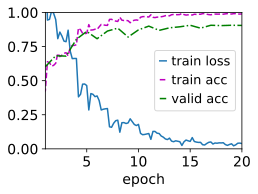

In [20]:
gpu_code_n=6
the_learning_rate = 0.01
the_epochs = 20
the_batch_size = 16
the_dropout = 0.3
the_num_workers = 4

# pcma = PCmaster_anno_0()
# pcma.auto_anno_mldl_train_0(ref_obj=scobj1,test_obj=scobj2,gpu_code = n,
#                             learning_rate=the_learning_rate,
#                             epochs=the_epochs,
#                             batch_size = the_batch_size,dropout = the_dropout,
#                             num_workers = the_num_workers)

with open('PCmaster_anno_0_23_10_3.py','r') as f:
    exec(f.read())
pcma = PCmaster_anno_0()
pcma.auto_annotation_with_deep_learning_0(original_obj=the_original_obj,gpu_code = gpu_code_n,
                                          learning_rate=the_learning_rate,
                                          epochs=the_epochs,
                                          batch_size = the_batch_size,dropout = the_dropout,
                                          num_workers = the_num_workers
                                          )

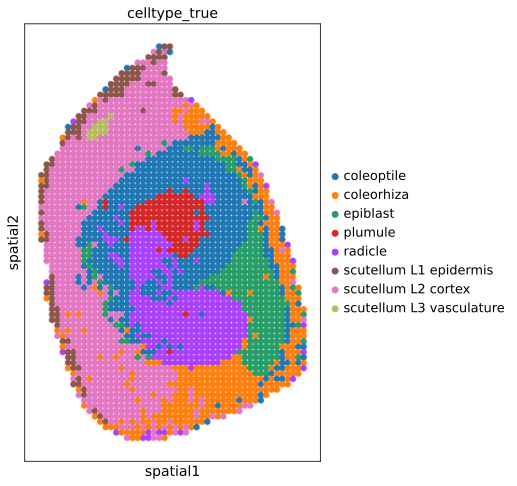

In [21]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.figsize"] = (8, 8)
sc.pl.spatial(scobj2, img_key="hires", color=['celltype_true'],spot_size = 60)

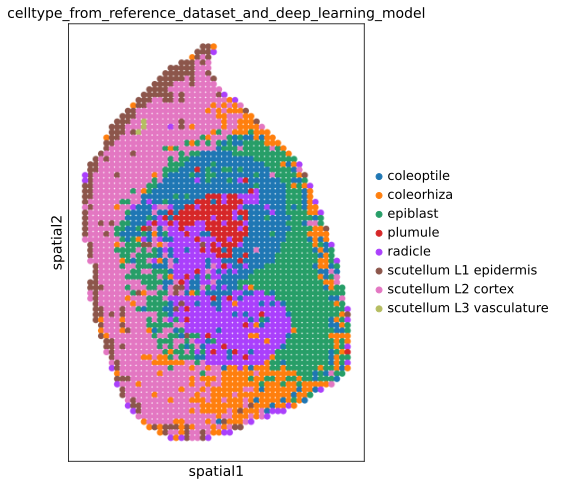

In [22]:
scobj2.obs['celltype_from_reference_dataset_and_deep_learning_model'] = pcma.predicted_results
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.figsize"] = (8, 8)
sc.pl.spatial(scobj2, img_key="hires", color=['celltype_from_reference_dataset_and_deep_learning_model'],spot_size = 60)

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
        
# 将预测结果和真实标签转换为 NumPy 数组
import numpy as np

def get_accu_prec_recall(the_pred = None,the_truth = None):
    original_list1 = the_pred
    original_list2 = the_truth
    original_list1.append('Unknown')
    original_list2.append('Unknown')
    categories1 = list(set(original_list1))
    categories2 = list(set(original_list2))
    
    for the_item in categories1:
        if the_item not in categories2:
            print('error')
    
    # 创建一个字典来映射类别和数字
    # category1_to_number = {category: number for number, category in enumerate(categories1)}
    category2_to_number = {category: number for number, category in enumerate(categories2)}
    
    # 将list中的类别转化为数字，一个类别分配一个数字
    new_list1 = [category2_to_number[category] for category in original_list1]
    new_list2 = [category2_to_number[category] for category in original_list2]
    
    # 将这个list变成全是数字的numpy格式的ndarray
    predicted = np.array(new_list1)
    test_label = np.array(new_list2)
    
    # 计算准确率（accuracy）  
    accuracy = accuracy_score(test_label, predicted)  
    
    # 计算宏平均精确率（macro precision）  
    macro_precision = precision_score(test_label, predicted, average='macro', zero_division=1)  
    
    # 计算宏平均召回率（macro recall）  
    macro_recall = recall_score(test_label, predicted, average='macro', zero_division=1)  
    
    # 计算宏平均F1分数（macro F1 score）  
    macro_f1_score = f1_score(test_label, predicted, average='macro', zero_division=1)  
    
    # 打印结果  
    print("Accuracy:", accuracy)  
    print("Macro Precision:", macro_precision)  
    print("Macro Recall:", macro_recall)  
    print("Macro F1 Score:", macro_f1_score) 
    
    return accuracy,macro_precision,macro_recall,macro_f1_score

In [24]:
the_pred1 = scobj2.obs['celltype_from_reference_dataset_and_deep_learning_model'].tolist()
the_truth1 = scobj2.obs['celltype_true'].tolist()

the_accuracy,the_precision,the_recall,the_f1_score = get_accu_prec_recall(the_pred = the_pred1,
                     the_truth = the_truth1)

Accuracy: 0.6825028968713789
Macro Precision: 0.7359756337721365
Macro Recall: 0.6869098209694935
Macro F1 Score: 0.6703407567251473


In [25]:
pred_list_tmp = scobj2.obs['celltype_from_reference_dataset_and_deep_learning_model']

In [26]:
tmp_list = []
for i in scobj2.obs['seurat_clusters']:
    tmp_list.append(str(i))
scobj2.obs['seurat_clusters_string'] = tmp_list

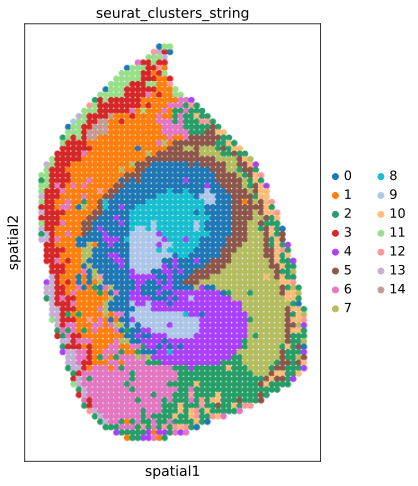

In [27]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.figsize"] = (8, 8)
sc.pl.spatial(scobj2, img_key="hires", color=['seurat_clusters_string'],spot_size = 60)

In [28]:
import numpy as np
import pandas as pd

scobj2_pd = pd.DataFrame({'cellname': scobj2.obs['cellname'], 'cluster': scobj2.obs['seurat_clusters'], 
                          'celltype': scobj2.obs['celltype_from_reference_dataset_and_deep_learning_model']})

# 聚类编号列表
cluster_list = list(set(scobj2.obs['seurat_clusters'].tolist()))

# 遍历聚类编号列表
for i in cluster_list:
    # 获取当前聚类编号下的所有细胞
    cells_in_cluster_i = scobj2_pd[scobj2_pd['cluster'] == i]
    # 获取当前聚类编号下的所有细胞的细胞类型
    celltypes_in_cluster_i = cells_in_cluster_i['celltype']
    # 获取当前聚类编号下的所有细胞的出现次数最多的细胞类型
    most_common_celltype_in_cluster_i = celltypes_in_cluster_i.value_counts().idxmax()
    # 将当前聚类编号下的所有细胞的细胞类型设置为出现次数最多的细胞类型
    scobj2_pd.loc[scobj2_pd['cluster'] == i, 'celltype'] = most_common_celltype_in_cluster_i

print(scobj2_pd)

scobj2.obs['celltype_pred_cluster_aftertreatment'] = scobj2_pd['celltype']

                      cellname  cluster                celltype
bin_100_1150_1  bin_100_1150_1       13  scutellum L1 epidermis
bin_100_1200_1  bin_100_1200_1       11  scutellum L1 epidermis
bin_100_1250_1  bin_100_1250_1       11  scutellum L1 epidermis
bin_100_1300_1  bin_100_1300_1       11  scutellum L1 epidermis
bin_100_1350_1  bin_100_1350_1       11  scutellum L1 epidermis
...                        ...      ...                     ...
bin_950_750_1    bin_950_750_1        1     scutellum L2 cortex
bin_950_800_1    bin_950_800_1        1     scutellum L2 cortex
bin_950_850_1    bin_950_850_1        1     scutellum L2 cortex
bin_950_900_1    bin_950_900_1        1     scutellum L2 cortex
bin_950_950_1    bin_950_950_1        1     scutellum L2 cortex

[2588 rows x 3 columns]


In [29]:
the_pred1 = scobj2.obs['celltype_pred_cluster_aftertreatment'].tolist()
the_truth1 = scobj2.obs['celltype_true'].tolist()

the_accuracy,the_precision,the_recall,the_f1_score = get_accu_prec_recall(the_pred = the_pred1,
                     the_truth = the_truth1)

Accuracy: 0.9953650057937428
Macro Precision: 0.9983395599833956
Macro Recall: 0.8888888888888888
Macro F1 Score: 0.8880524187926948


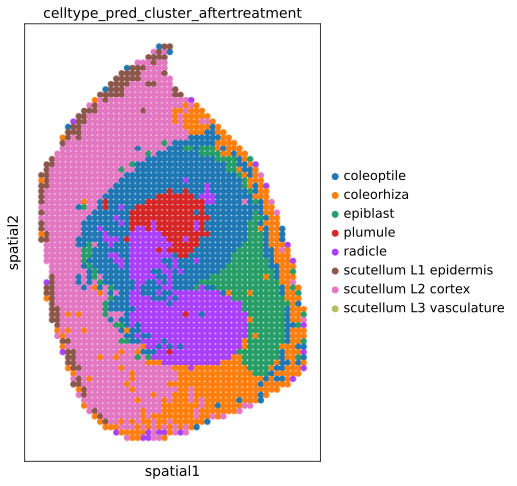

In [30]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.figsize"] = (8, 8)
sc.pl.spatial(scobj2, img_key="hires", color=['celltype_pred_cluster_aftertreatment'],spot_size = 60)

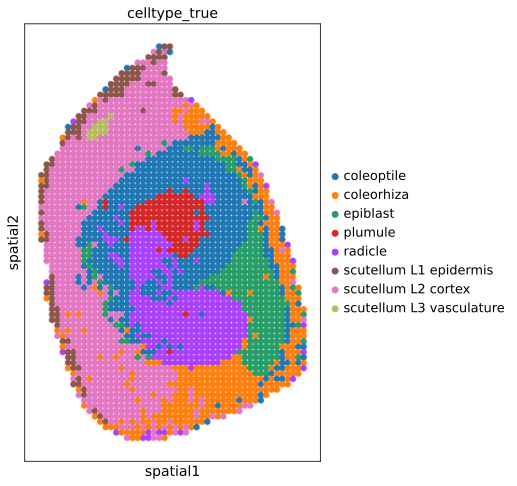

In [31]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.figsize"] = (8, 8)
sc.pl.spatial(scobj2, img_key="hires", color=['celltype_true'],spot_size = 60)